# Explainable AML transaction monitoring with SAML-D

This one-notebook class project compares **logistic regression, XGBoost, and Explainable Boosting Machine (EBM)** on the full synthetic SAML-D transaction dataset. It uses past transaction activity to form simple account-history features, validates in time order, chooses alert thresholds on validation data, and reports later test results. Each model has its own scorecard and explanation; XGBoost uses Tree SHAP.

**Task:** rank transactions with the dataset's `Is_laundering` label for review. A positive synthetic label is not a confirmed crime or a bank investigation outcome. `Laundering_type` is reserved for the final coverage analysis and **never enters a model** because it describes the target.

## 1. Imports and dataset path

Download `SAML-D.csv` into `data/raw/` using the instructions in [README.md](README.md). Run the cells in order using the project's `.venv` kernel.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, DMatrix
from interpret.glassbox import ExplainableBoostingClassifier

DATA_PATH = Path("data/raw/SAML-D.csv")
SEED = 42
print("Dataset:", DATA_PATH)

Dataset: data/raw/SAML-D.csv


## 2. Load and profile all transactions

SAML-D has dates, sender and receiver account IDs, amount, currencies, bank locations, payment type, a binary target, and a laundering typology. We read every row. The tables below show the label balance, payment-type coverage, and monthly timeline before modeling.

In [2]:
category_columns = ["Payment_currency", "Received_currency", "Sender_bank_location",
                    "Receiver_bank_location", "Payment_type", "Laundering_type"]
dtypes = {column: "category" for column in category_columns}
dtypes.update({"Sender_account": "int64", "Receiver_account": "int64",
               "Amount": "float32", "Is_laundering": "int8"})
transactions = pd.read_csv(DATA_PATH, dtype=dtypes)
transactions["timestamp"] = pd.to_datetime(transactions.pop("Date") + " " + transactions.pop("Time"))
transactions = transactions.sort_values("timestamp", kind="stable").reset_index(drop=True)

n_rows = len(transactions)
n_positive = int(transactions["Is_laundering"].sum())
print(f"Rows: {n_rows:,} | positive labels: {n_positive:,} ({n_positive/n_rows:.3%})")
print("Date range:", transactions["timestamp"].min(), "to", transactions["timestamp"].max())
print("Missing values:", int(transactions.isna().sum().sum()))
profile_by_type = transactions.groupby("Payment_type", observed=True)["Is_laundering"].agg(["size", "sum"])
profile_by_type["positive_rate_pct"] = 100 * profile_by_type["sum"] / profile_by_type["size"]
display(profile_by_type.rename(columns={"size": "rows", "sum": "positive_labels"}).round(4))
monthly_profile = transactions.groupby(transactions["timestamp"].dt.to_period("M"))["Is_laundering"].agg(["size", "sum"])
monthly_profile["positive_rate_pct"] = 100 * monthly_profile["sum"] / monthly_profile["size"]
display(monthly_profile.rename(columns={"size": "rows", "sum": "positive_labels"}).round(4))

Rows: 9,504,852 | positive labels: 9,873 (0.104%)
Date range: 2022-10-07 10:35:19 to 2023-08-23 10:57:12
Missing values: 0


,rows,positive_labels,positive_rate_pct
Payment_type,,,
ACH,2008807,1159,0.0577
Cash Deposit,225206,1405,0.6239
Cash Withdrawal,300477,1334,0.4440
Cheque,2011419,1087,0.0540
Credit card,2012909,1136,0.0564
Cross-border,933931,2628,0.2814
Debit card,2012103,1124,0.0559


,rows,positive_labels,positive_rate_pct
timestamp,,,
2022-10,708654,694,0.0979
2022-11,897621,794,0.0885
2022-12,900341,907,0.1007
2023-01,908320,940,0.1035
2023-02,904806,946,0.1046
2023-03,908562,927,0.1020
2023-04,902883,962,0.1065
2023-05,917601,866,0.0944
2023-06,897243,1024,0.1141


## 3. Build simple features from current and earlier transactions

Raw account IDs connect past activity, but are not model predictors. For each transaction we count earlier activity by sender, receiver, and sender–receiver pair. A second payment in the **same second** does not count as earlier. We compare the payment with that sender's earlier average amount in the **same payment currency**. Every original transaction field contributes either an input, a history link, the time split, the label, or the later typology audit.

In [3]:
for keys, name in [
    (["Sender_account"], "prior_sender_count"),
    (["Receiver_account"], "prior_receiver_count"),
    (["Sender_account", "Receiver_account"], "prior_pair_count"),
]:
    earlier = transactions.groupby(keys, sort=False, observed=True).cumcount()
    same_second = transactions.groupby(keys + ["timestamp"], sort=False, observed=True).cumcount()
    transactions[name] = (earlier - same_second).astype("int32")

currency_keys = ["Sender_account", "Payment_currency"]
past_count = (
    transactions.groupby(currency_keys, sort=False, observed=True).cumcount()
    - transactions.groupby(currency_keys + ["timestamp"], sort=False, observed=True).cumcount()
)
transactions["prior_sender_currency_count"] = past_count.astype("int32")
past_amount = (
    transactions.groupby(currency_keys, sort=False, observed=True)["Amount"].cumsum()
    - transactions.groupby(currency_keys + ["timestamp"], sort=False, observed=True)["Amount"].cumsum()
)
past_average = past_amount / past_count.replace(0, np.nan)
transactions["log_prior_sender_mean_amount"] = np.log1p(past_average.clip(lower=0)).fillna(0).astype("float32")
transactions["log_amount"] = np.log1p(transactions["Amount"]).astype("float32")
transactions["hour"] = transactions["timestamp"].dt.hour.astype("int8")
transactions["weekday"] = transactions["timestamp"].dt.weekday.astype("int8")
transactions["same_account"] = (transactions["Sender_account"] == transactions["Receiver_account"]).astype("int8")
transactions["same_bank_location"] = (transactions["Sender_bank_location"] == transactions["Receiver_bank_location"]).astype("int8")
transactions["same_currency"] = (transactions["Payment_currency"] == transactions["Received_currency"]).astype("int8")
transactions["amount_vs_sender_usual"] = np.where(
    transactions["prior_sender_count"] > 0,
    np.abs(transactions["log_amount"] - transactions["log_prior_sender_mean_amount"]), 0
).astype("float32")
transactions = transactions.drop(columns=["Sender_account", "Receiver_account", "Amount"])
del earlier, same_second, past_count, past_amount, past_average

display(transactions[["timestamp", "log_amount", "prior_sender_count",
                      "prior_receiver_count", "prior_pair_count",
                      "log_prior_sender_mean_amount"]].head())

,timestamp,log_amount,prior_sender_count,prior_receiver_count,prior_pair_count,log_prior_sender_mean_amount
0,2022-10-07 10:35:19,7.286294,0,0,0,0.0
1,2022-10-07 10:35:20,8.702949,0,0,0,0.0
2,2022-10-07 10:35:20,9.570071,0,0,0,0.0
3,2022-10-07 10:35:21,9.383958,0,0,0,0.0
4,2022-10-07 10:35:21,4.755743,0,0,0,0.0


## 4. Split by time and choose inputs

The first 70% of calendar days are training, the next 15% validation, and the final 15% testing. These are approximate **row** percentages because the number of transactions differs by day. The later test is held out while models and thresholds are chosen. Categorical transaction fields stay categorical for XGBoost and EBM; logistic regression learns one-hot categories from training data only.

In [4]:
days = transactions["timestamp"].dt.normalize().drop_duplicates().to_numpy()
train_end = pd.Timestamp(days[int(len(days) * 0.70)])
test_start = pd.Timestamp(days[int(len(days) * 0.85)])
train = transactions.loc[transactions["timestamp"] < train_end].copy()
validation = transactions.loc[(transactions["timestamp"] >= train_end) &
                              (transactions["timestamp"] < test_start)].copy()
test = transactions.loc[transactions["timestamp"] >= test_start].copy()
del transactions

numeric_features = ["log_amount", "hour", "weekday", "same_account",
                    "same_bank_location", "same_currency", "prior_sender_count",
                    "prior_receiver_count", "prior_pair_count", "prior_sender_currency_count",
                    "log_prior_sender_mean_amount", "amount_vs_sender_usual"]
categorical_features = ["Payment_currency", "Received_currency",
                        "Sender_bank_location", "Receiver_bank_location", "Payment_type"]
features = numeric_features + categorical_features
label = "Is_laundering"

split_summary = pd.DataFrame([
    {"period": name, "start": frame["timestamp"].min().date(),
     "end": frame["timestamp"].max().date(), "rows": len(frame),
     "positive_labels": int(frame[label].sum())}
    for name, frame in [("train", train), ("validation", validation), ("test", test)]
])
split_summary["row_share_pct"] = 100 * split_summary["rows"] / n_rows
split_summary["positive_rate_pct"] = 100 * split_summary["positive_labels"] / split_summary["rows"]
display(split_summary.round(4))
print("Model inputs:", features)
print("Held out from inputs: account IDs, timestamp, target, Laundering_type")

,period,start,end,rows,positive_labels,row_share_pct,positive_rate_pct
0,train,2022-10-07,2023-05-18,6661223,6774,70.0823,0.1017
1,validation,2023-05-19,2023-07-05,1430805,1416,15.0534,0.0990
2,test,2023-07-06,2023-08-23,1412824,1683,14.8642,0.1191


Model inputs: ['log_amount', 'hour', 'weekday', 'same_account', 'same_bank_location', 'same_currency', 'prior_sender_count', 'prior_receiver_count', 'prior_pair_count', 'prior_sender_currency_count', 'log_prior_sender_mean_amount', 'amount_vs_sender_usual', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']
Held out from inputs: account IDs, timestamp, target, Laundering_type


## 5. Define three explainable models

- **Logistic regression** is a weighted sum of standardized numeric inputs and one-hot categories.
- **XGBoost** uses 100 shallow trees (depth 3) and supports native categories. Tree SHAP explains its scores below.
- **EBM** adds one learned effect per input with interactions turned off.

Positive training rows get 10 times the weight of negative rows to make the rare labels matter during fitting. Alert thresholds are chosen separately on validation data.

In [5]:
positive_weight = 10
logistic_preprocessor = ColumnTransformer([
    ("number", StandardScaler(), numeric_features),
    ("category", OneHotEncoder(handle_unknown="ignore", dtype=np.float32), categorical_features),
], sparse_threshold=1.0)
models = {
    "Logistic regression": make_pipeline(
        logistic_preprocessor, LogisticRegression(max_iter=250, solver="lbfgs")
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.08,
        scale_pos_weight=positive_weight, enable_categorical=True,
        tree_method="hist", max_bin=128, n_jobs=4,
        eval_metric="logloss", random_state=SEED,
    ),
    "EBM": ExplainableBoostingClassifier(
        interactions=0, outer_bags=1, max_rounds=120, max_bins=64,
        n_jobs=4, random_state=SEED,
    ),
}
print("Models:", ", ".join(models))

Models: Logistic regression, XGBoost, EBM


## 6. Time-ordered cross-validation inside training

Each fold fits on all activity before its check window. Its next block of days is used only for ranking evaluation. Average precision (AP) measures how well each model ranks positive labels above negatives across thresholds. We choose the model family by mean fold AP, then fit all three final models on the full training period.

In [6]:
train_days = train["timestamp"].dt.normalize().drop_duplicates().to_numpy()
fold_starts = [pd.Timestamp(train_days[int(len(train_days) * part)])
               for part in (0.40, 0.60, 0.80)]
fold_ends = fold_starts[1:] + [train_end]
fold_rows = []
for name, model in models.items():
    for check_start, check_end in zip(fold_starts, fold_ends):
        fit_rows = train["timestamp"] < check_start
        check_rows = (train["timestamp"] >= check_start) & (train["timestamp"] < check_end)
        X_fit = train.loc[fit_rows, features]
        y_fit = train.loc[fit_rows, label]
        X_check = train.loc[check_rows, features]
        y_check = train.loc[check_rows, label]
        weights = np.where(y_fit.to_numpy() == 1, positive_weight, 1.0)
        fitted = clone(model)
        if name == "Logistic regression":
            fitted.fit(X_fit, y_fit, logisticregression__sample_weight=weights)
        elif name == "EBM":
            fitted.fit(X_fit, y_fit, sample_weight=weights)
        else:
            fitted.fit(X_fit, y_fit)
        score = fitted.predict_proba(X_check)[:, 1]
        fold_rows.append({"model": name, "check_start": check_start.date(),
                          "check_end": (check_end - pd.Timedelta(days=1)).date(),
                          "rows": len(y_check), "positive_labels": int(y_check.sum()),
                          "average_precision": average_precision_score(y_check, score)})
        print(name, check_start.date(), "AP", round(fold_rows[-1]["average_precision"], 4))
        del fitted, X_fit, X_check, y_fit, y_check, score

fold_results = pd.DataFrame(fold_rows)
fold_summary = fold_results.groupby("model")["average_precision"].mean().sort_values(ascending=False)
selected_model = fold_summary.index[0]
print("Mean AP by model:")
display(fold_summary.to_frame("mean_ap").round(4))
print("Selected model:", selected_model)
display(fold_results.round(4))

Logistic regression 2023-01-04 AP 0.0724


Logistic regression 2023-02-18 AP 0.0897


Logistic regression 2023-04-04 AP 0.0776


XGBoost 2023-01-04 AP 0.7737


XGBoost 2023-02-18 AP 0.869


...

EBM 2023-02-18 AP 0.3823


EBM 2023-04-04 AP 0.4324
Mean AP by model:


,mean_ap
model,
XGBoost,0.8376
EBM,0.3306
Logistic regression,0.0799


Selected model: XGBoost


,model,check_start,check_end,rows,positive_labels,average_precision
0,Logistic regression,2023-01-04,2023-02-17,1370726,1523,0.0724
1,Logistic regression,2023-02-18,2023-04-03,1357004,1297,0.0897
2,Logistic regression,2023-04-04,2023-05-18,1337988,1505,0.0776
3,XGBoost,2023-01-04,2023-02-17,1370726,1523,0.7737
4,XGBoost,2023-02-18,2023-04-03,1357004,1297,0.8690
5,XGBoost,2023-04-04,2023-05-18,1337988,1505,0.8700
6,EBM,2023-01-04,2023-02-17,1370726,1523,0.1771
7,EBM,2023-02-18,2023-04-03,1357004,1297,0.3823
8,EBM,2023-04-04,2023-05-18,1337988,1505,0.4324


## 7. Fit final models on all training rows

In [7]:
X_train = train[features]
y_train = train[label]
weights = np.where(y_train.to_numpy() == 1, positive_weight, 1.0)
models["Logistic regression"].fit(X_train, y_train, logisticregression__sample_weight=weights)
print("Fitted logistic regression")
models["XGBoost"].fit(X_train, y_train)
print("Fitted XGBoost")
models["EBM"].fit(X_train, y_train, sample_weight=weights)
print("Fitted EBM on", f"{len(train):,}", "training transactions")

Fitted logistic regression


Fitted XGBoost


Fitted EBM on 6,661,223 training transactions


## 8. Set alert thresholds on validation and evaluate the later test

For each model, use the **validation threshold with highest F1**. This gives a simple, consistent operating point. Report AP, precision, recall, F1, false positive rate (FPR), alert count, and missed positives on both periods. AP evaluates ranking; the other metrics depend on the selected threshold. These are evaluation measures, not universal bank or regulatory targets.

In [8]:
def metric_row(name, period, truth, score, threshold):
    alerts = score >= threshold
    tn, fp, fn, tp = confusion_matrix(truth, alerts, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    return {"model": name, "period": period,
            "average_precision": average_precision_score(truth, score),
            "precision": precision, "recall": recall,
            "f1": 2 * precision * recall / (precision + recall) if precision + recall else 0,
            "false_positive_rate": fp / (fp + tn), "alerts": int(tp + fp),
            "true_positives": int(tp), "missed_positives": int(fn),
            "false_positives": int(fp)}

rows = []
scores = {}
thresholds = {}
for name, model in models.items():
    validation_score = model.predict_proba(validation[features])[:, 1]
    precision_curve, recall_curve, cutoffs = precision_recall_curve(
        validation[label], validation_score
    )
    f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / (
        precision_curve[:-1] + recall_curve[:-1] + 1e-12
    )
    thresholds[name] = float(cutoffs[np.argmax(f1_curve)])
    test_score = model.predict_proba(test[features])[:, 1]
    scores[(name, "validation")] = validation_score
    scores[(name, "test")] = test_score
    rows.append(metric_row(name, "validation", validation[label], validation_score, thresholds[name]))
    rows.append(metric_row(name, "test", test[label], test_score, thresholds[name]))
    print(name, "validation threshold", round(thresholds[name], 5))
results = pd.DataFrame(rows)
display(results.round(4))
print("Selected model:", selected_model)
selected_alerts = scores[(selected_model, "test")] >= thresholds[selected_model]
display(pd.DataFrame(confusion_matrix(test[label], selected_alerts, labels=[0, 1]),
                     index=["actual negative", "actual positive"],
                     columns=["no alert", "alert"]))

Logistic regression validation threshold 0.20113


XGBoost validation threshold 0.59512


EBM validation threshold 0.22463


,model,period,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,missed_positives,false_positives
0,Logistic regression,validation,0.0922,0.1528,0.1970,0.1721,0.0011,1826,279,1137,1547
1,Logistic regression,test,0.1336,0.2118,0.2175,0.2146,0.0010,1728,366,1317,1362
2,XGBoost,validation,0.8856,0.9703,0.8079,0.8817,0.0000,1179,1144,272,35
3,XGBoost,test,0.8959,0.9384,0.8414,0.8872,0.0001,1509,1416,267,93
4,EBM,validation,0.4784,0.8424,0.4040,0.5461,0.0001,679,572,844,107
5,EBM,test,0.5100,0.8932,0.4124,0.5642,0.0001,777,694,989,83


Selected model: XGBoost


,no alert,alert
actual negative,1411048,93
actual positive,267,1416


## 8.1 Investigate missed labels by payment type and laundering typology

The dataset's `Laundering_type` field is used **only here, after scoring**, to see which labeled patterns the selected model misses. This is a coverage audit, not a feature. Very small typologies should be interpreted cautiously.

In [9]:
audit = test[["Payment_type", "Laundering_type", label]].copy()
audit["alert"] = selected_alerts
by_type = audit.groupby("Payment_type", observed=True).agg(
    rows=(label, "size"), positive_labels=(label, "sum"), alerts=("alert", "sum")
)
by_type["caught"] = audit.loc[audit[label] == 1].groupby("Payment_type", observed=True)["alert"].sum()
by_type["caught"] = by_type["caught"].fillna(0).astype(int)
by_type["missed"] = by_type["positive_labels"] - by_type["caught"]
by_type["recall"] = by_type["caught"] / by_type["positive_labels"].replace(0, np.nan)
print("Selected model by payment type:")
display(by_type.round(4))

positive_audit = audit.loc[audit[label] == 1]
by_typology = positive_audit.groupby("Laundering_type", observed=True)["alert"].agg(["size", "sum"])
by_typology = by_typology.rename(columns={"size": "positive_labels", "sum": "caught"})
by_typology["missed"] = by_typology["positive_labels"] - by_typology["caught"]
by_typology["recall"] = by_typology["caught"] / by_typology["positive_labels"]
print("Selected model by positive typology:")
display(by_typology.sort_values("missed", ascending=False).round(4))

Selected model by payment type:


,rows,positive_labels,alerts,caught,missed,recall
Payment_type,,,,,,
ACH,299093,176,165,165,11,0.9375
Cash Deposit,33662,232,146,117,115,0.5043
Cash Withdrawal,44376,237,174,157,80,0.6624
Cheque,299066,165,155,155,10,0.9394
Credit card,298851,193,188,188,5,0.9741
Cross-border,138748,477,486,439,38,0.9203
Debit card,299028,203,195,195,8,0.9606


Selected model by positive typology:


,positive_labels,caught,missed,recall
Laundering_type,,,,
Smurfing,151,36,115,0.2384
Cash_Withdrawal,237,157,80,0.6624
Behavioural_Change_1,62,27,35,0.4355
Behavioural_Change_2,59,43,16,0.7288
Layered_Fan_Out,100,92,8,0.9200
Deposit-Send,163,158,5,0.9693
Cycle,49,46,3,0.9388
Gather-Scatter,82,80,2,0.9756
Single_large,33,32,1,0.9697


## 9. Individual model results and explanations

Every model gets its own validation-versus-test metric chart. The explanation charts show how the model calculated scores; they do not establish why a transaction was labeled suspicious.

In [10]:
def show_model_scorecard(name):
    model_results = results.loc[results["model"] == name]
    print(name, "| threshold:", round(thresholds[name], 5))
    display(model_results.drop(columns="model").round(4))
    metrics = [("average_precision", "Average precision"),
               ("precision", "Precision"), ("recall", "Recall"),
               ("f1", "F1"), ("false_positive_rate", "False positive rate")]
    fig, axes = plt.subplots(1, len(metrics), figsize=(17, 3.5))
    for ax, (metric, title) in zip(axes, metrics):
        values = model_results[metric].to_numpy()
        bars = ax.bar(["Validation", "Test"], values, color=["#4477AA", "#EE8866"])
        labels = [f"{v:.3%}" if metric == "false_positive_rate" else f"{v:.1%}" for v in values]
        ax.bar_label(bars, labels=labels, padding=2, fontsize=8)
        ax.set_ylim(0, max(values) * 1.35 if metric == "false_positive_rate" else 1)
        ax.set_title(title)
        ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=3 if metric == "false_positive_rate" else 0))
        ax.tick_params(axis="x", labelrotation=25)
    fig.suptitle(name + ": validation vs later test")
    fig.tight_layout()
    plt.show()

### 9.1 Logistic regression

**Later test:** AP **0.1336**, precision **21.2%**, recall **21.7%**, F1 **0.2146**, and FPR **0.0965%**. It catches **366 of 1,683** positive labels in **1,728** alerts and misses **1,317**. This simple weighted-sum model is easy to explain, but its test alert workload and missed-label count are both high compared with XGBoost.

The coefficient chart shows which standardized numeric input or one-hot category raises or lowers the raw score. The local chart shows the largest contributions for one high-scored test transaction. Coefficients describe this fitted model's associations, not causes of laundering.

Logistic regression | threshold: 0.20113


,period,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,missed_positives,false_positives
0,validation,0.0922,0.1528,0.1970,0.1721,0.0011,1826,279,1137,1547
1,test,0.1336,0.2118,0.2175,0.2146,0.0010,1728,366,1317,1362


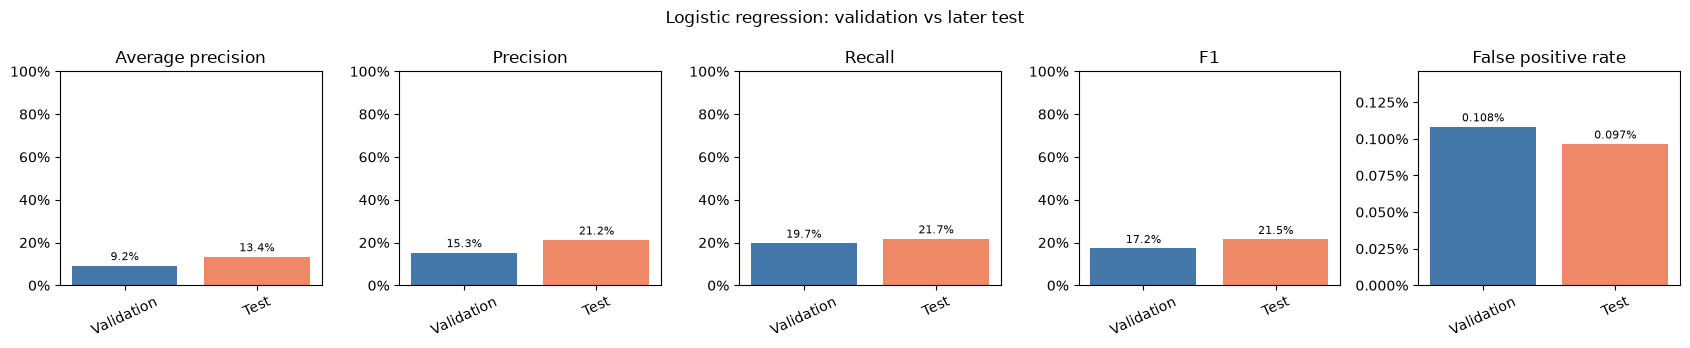

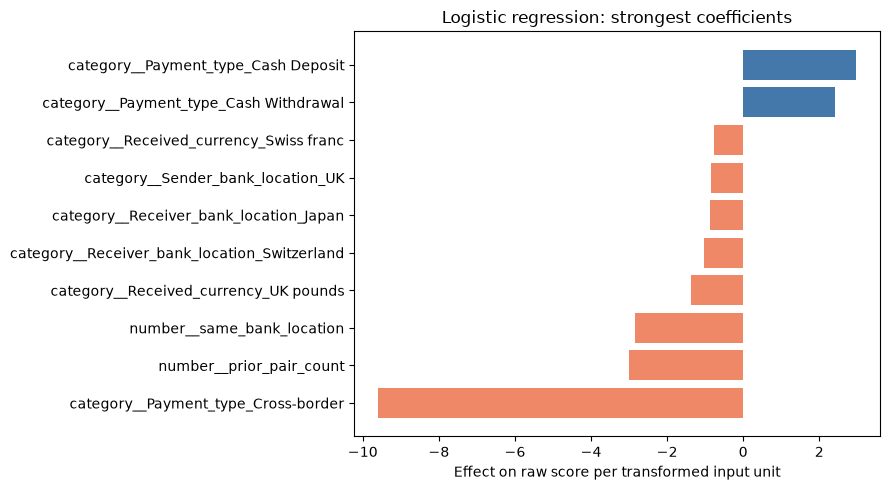

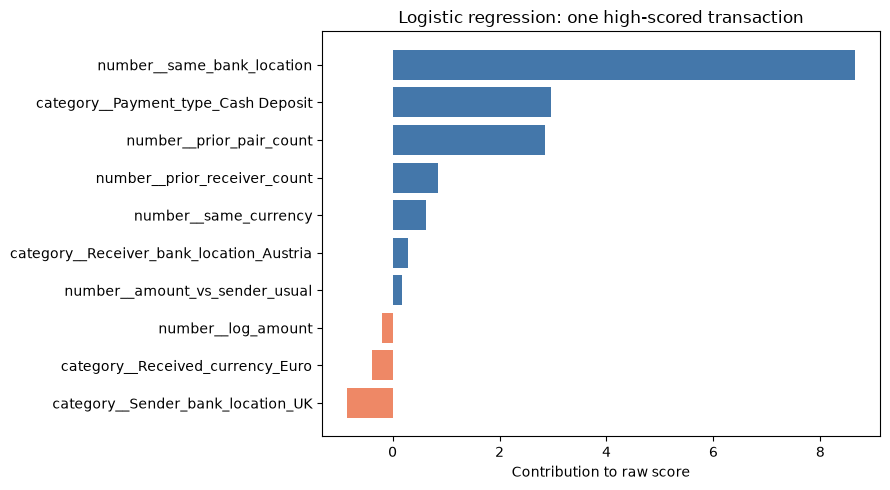

Example label: 1


In [11]:
show_model_scorecard("Logistic regression")
logistic_pipeline = models["Logistic regression"]
logistic = logistic_pipeline.named_steps["logisticregression"]
encoder = logistic_pipeline.named_steps["columntransformer"]
logistic_names = encoder.get_feature_names_out()
coefficients = pd.Series(logistic.coef_[0], index=logistic_names)
top = coefficients.loc[coefficients.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top, color=np.where(top >= 0, "#4477AA", "#EE8866"))
ax.set_title("Logistic regression: strongest coefficients")
ax.set_xlabel("Effect on raw score per transformed input unit")
fig.tight_layout()
plt.show()

logistic_row = int(np.argmax(scores[("Logistic regression", "test")]))
encoded_row = encoder.transform(test[features].iloc[[logistic_row]]).toarray()[0]
local_parts = pd.Series(encoded_row * logistic.coef_[0], index=logistic_names)
top_local = local_parts.loc[local_parts.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_local.index, top_local, color=np.where(top_local >= 0, "#4477AA", "#EE8866"))
ax.set_title("Logistic regression: one high-scored transaction")
ax.set_xlabel("Contribution to raw score")
fig.tight_layout()
plt.show()
print("Example label:", int(test[label].iloc[logistic_row]))

### 9.2 XGBoost with Tree SHAP

**Later test:** AP **0.8959**, precision **93.8%**, recall **84.1%**, F1 **0.8872**, and FPR **0.0066%**. It catches **1,416 of 1,683** positive labels in **1,509** alerts and misses **267**. It was selected by the earlier time folds, not by these test results. The coverage table above shows that **115** of its misses are Cash Deposits and **80** are Cash Withdrawals.

Tree SHAP attributes the model's **raw score** to inputs. On the illustrated sample of 500 test rows, prior sender–receiver pair count and payment type have the largest average absolute contributions. That sample mostly contains negative labels because positives are rare. The local chart explains one high-scored transaction. SHAP contributions plus the bias add to the raw score, not to the displayed probability-like model score. These explanations describe the model's calculation, not the reason a transaction was generated with a positive label.

XGBoost | threshold: 0.59512


,period,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,missed_positives,false_positives
2,validation,0.8856,0.9703,0.8079,0.8817,0.0000,1179,1144,272,35
3,test,0.8959,0.9384,0.8414,0.8872,0.0001,1509,1416,267,93


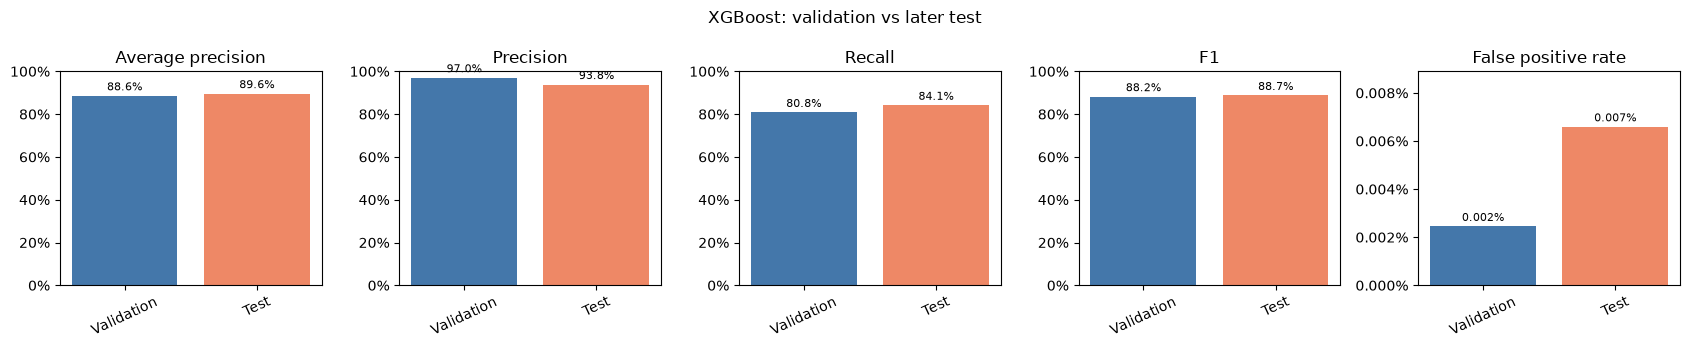

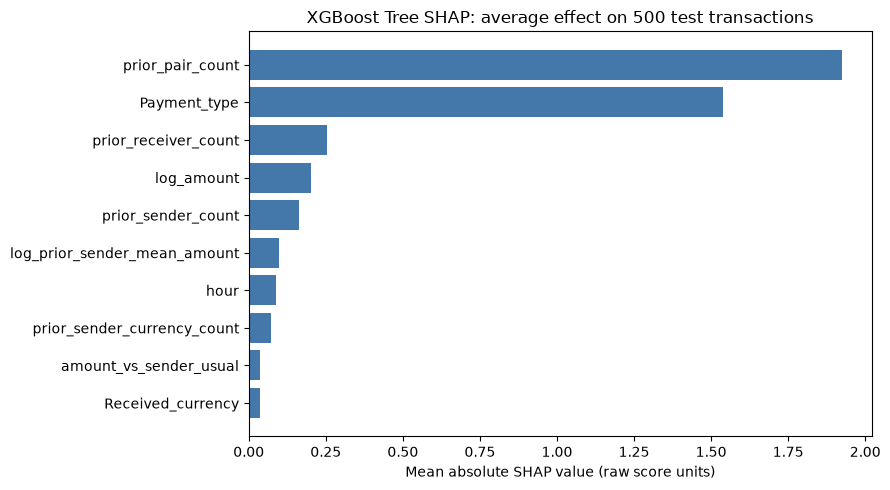

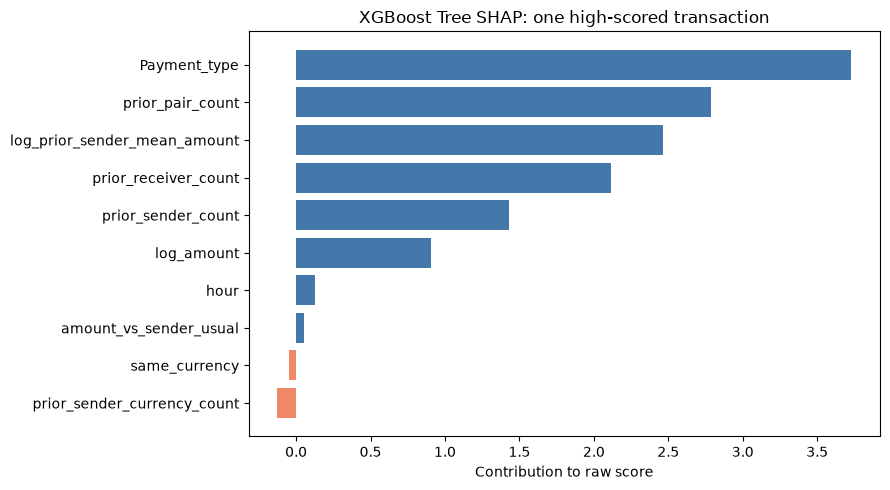

Example label: 1 | Tree SHAP contributions plus bias: 8.2003


In [12]:
show_model_scorecard("XGBoost")
xgboost = models["XGBoost"]
booster = xgboost.get_booster()
shap_sample = test[features].sample(n=500, random_state=SEED)
shap_values = booster.predict(DMatrix(shap_sample, enable_categorical=True), pred_contribs=True)
mean_abs_shap = pd.Series(np.abs(shap_values[:, :-1]).mean(axis=0), index=features)
top = mean_abs_shap.nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top, color="#4477AA")
ax.set_title("XGBoost Tree SHAP: average effect on 500 test transactions")
ax.set_xlabel("Mean absolute SHAP value (raw score units)")
fig.tight_layout()
plt.show()

xgb_row = int(np.argmax(scores[("XGBoost", "test")]))
local_values = booster.predict(
    DMatrix(test[features].iloc[[xgb_row]], enable_categorical=True), pred_contribs=True
)[0]
local_shap = pd.Series(local_values[:-1], index=features)
top_local = local_shap.loc[local_shap.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_local.index, top_local,
        color=np.where(top_local >= 0, "#4477AA", "#EE8866"))
ax.set_title("XGBoost Tree SHAP: one high-scored transaction")
ax.set_xlabel("Contribution to raw score")
fig.tight_layout()
plt.show()
print("Example label:", int(test[label].iloc[xgb_row]),
      "| Tree SHAP contributions plus bias:", round(float(local_values.sum()), 4))

### 9.3 Explainable Boosting Machine

**Later test:** AP **0.5100**, precision **89.3%**, recall **41.2%**, F1 **0.5642**, and FPR **0.0059%**. EBM catches **694 of 1,683** positive labels in **777** alerts and misses **989**. It generates the fewest alerts and false alerts of the three, but catches much less labeled activity than XGBoost at its validation-selected threshold.

EBM adds one learned effect per input, with no interaction terms. Term importance shows its main inputs; the local chart displays the additive pieces of one high-scored test transaction.

EBM | threshold: 0.22463


,period,average_precision,precision,recall,f1,false_positive_rate,alerts,true_positives,missed_positives,false_positives
4,validation,0.4784,0.8424,0.4040,0.5461,0.0001,679,572,844,107
5,test,0.5100,0.8932,0.4124,0.5642,0.0001,777,694,989,83


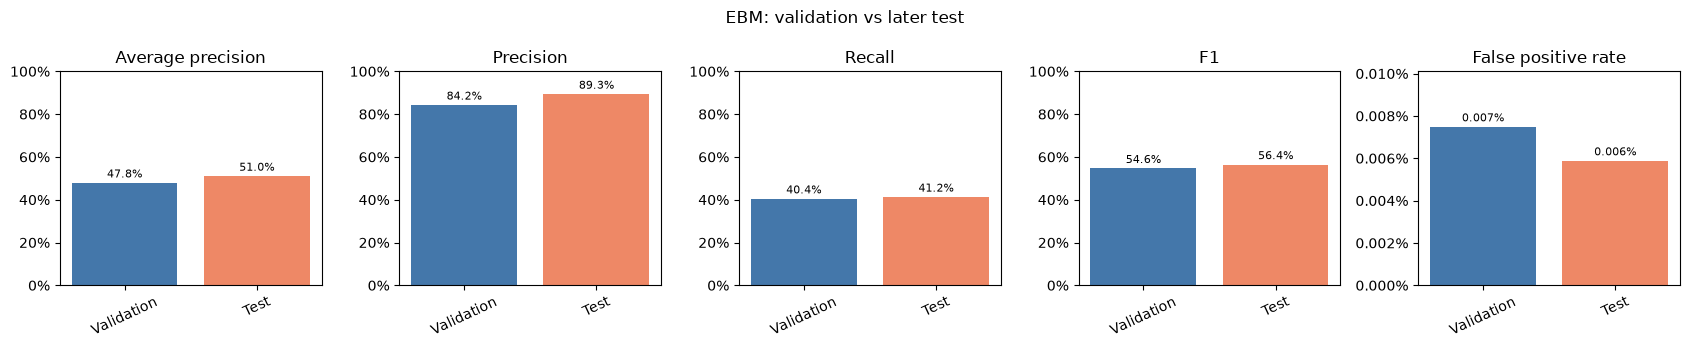

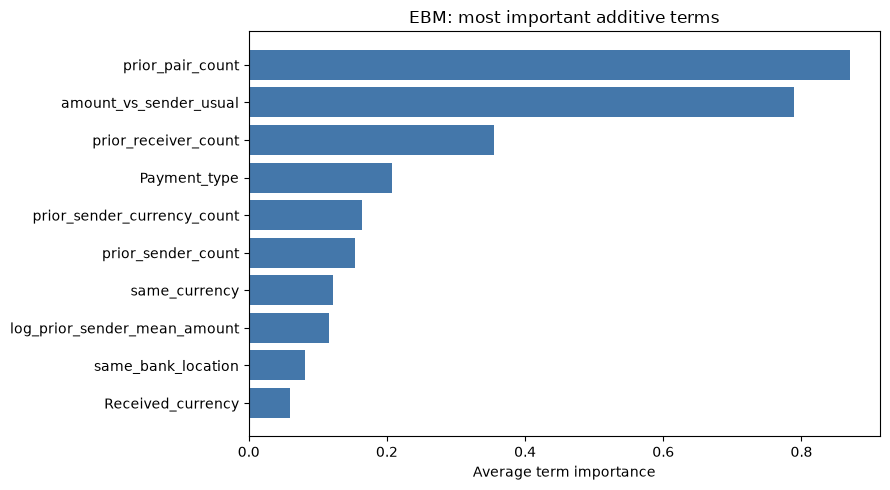

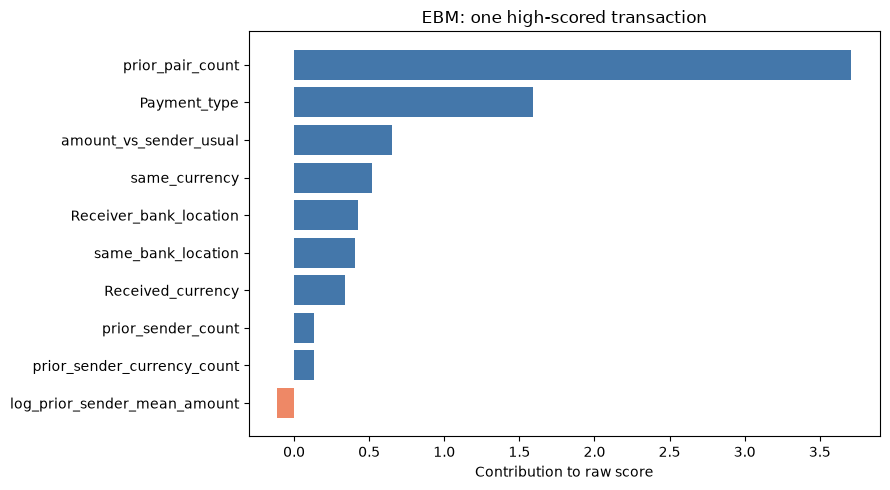

Example label: 1


In [13]:
show_model_scorecard("EBM")
ebm = models["EBM"]
importance = pd.Series(ebm.term_importances(), index=ebm.term_names_)
top = importance.nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top, color="#4477AA")
ax.set_title("EBM: most important additive terms")
ax.set_xlabel("Average term importance")
fig.tight_layout()
plt.show()

ebm_row = int(np.argmax(scores[("EBM", "test")]))
local_terms = pd.Series(ebm.eval_terms(test[features].iloc[[ebm_row]])[0], index=ebm.term_names_)
top_local = local_terms.loc[local_terms.abs().nlargest(10).index].sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_local.index, top_local,
        color=np.where(top_local >= 0, "#4477AA", "#EE8866"))
ax.set_title("EBM: one high-scored transaction")
ax.set_xlabel("Contribution to raw score")
fig.tight_layout()
plt.show()
print("Example label:", int(test[label].iloc[ebm_row]))

## 10. Conclusion to discuss in class

**XGBoost is the best of these three models for this SAML-D experiment.** It has the highest mean AP across the earlier time folds and the strongest later test AP, precision, recall, and F1. Its 267 missed positives still matter: the typology audit finds **115 of 151 Smurfing** labels missed, and Cash Deposit recall is only **50.4%**. The model comparison therefore needs both aggregate metrics and pattern-specific coverage.

The very high XGBoost scores should be presented as results on **synthetic generated labels**, not expected U.S. bank performance. `Laundering_type` was excluded from training, but the generator may still create unusually clear patterns in other fields. A bank would need reliable real investigation outcomes, risk coverage checks, alert-capacity planning, independent validation, and monitoring over time before operational use.

In [14]:
best_test = results.loc[(results["model"] == selected_model) &
                        (results["period"] == "test")].iloc[0]
print("Model selected using earlier time folds:", selected_model)
print(f"Later test: AP {best_test['average_precision']:.3f}, precision {best_test['precision']:.1%}, "
      f"recall {best_test['recall']:.1%}, F1 {best_test['f1']:.3f}, "
      f"FPR {best_test['false_positive_rate']:.3%}")
print(f"Alerts: {best_test['alerts']:,}; caught: {best_test['true_positives']:,}; "
      f"missed: {best_test['missed_positives']:,}")
print("These counts compare model alerts with synthetic labels, not confirmed crimes.")

Model selected using earlier time folds: XGBoost
Later test: AP 0.896, precision 93.8%, recall 84.1%, F1 0.887, FPR 0.007%
Alerts: 1,509; caught: 1,416; missed: 267
These counts compare model alerts with synthetic labels, not confirmed crimes.
